In [3]:
import pandas as pd

df = pd.read_json('/content/sample_data/netflix_edge_logs_raw.json', lines=True)
df.head()

,timestamp,session_id,edge_server_ip,latency_ms,bitrate_kbps,buffer_events,resolution,device_type
0,2026-04-08 12:36:49.466659+00:00,8b0b7f19,10.0.0.6,35,2766,0,1080p,Console
1,2026-04-09 10:37:46.466659+00:00,58ecc91e,10.0.0.6,47,3282,0,480p,Console
2,2026-04-08 22:37:05.466659+00:00,18bd4471,192.168.1.10,45,3715,1,1080p,None
3,2026-04-09 05:45:01.466659+00:00,87b0d03f,192.168.1.10,29,4720,0,720p,Smart TV
4,2026-04-08 16:57:03.466659+00:00,38310e92,192.168.1.10,52,3648,0,4K,Mobile


Basic Cleaning

In [4]:
# Check null values
df.isnull().sum()

# Drop duplicates
df = df.drop_duplicates()

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

/tmp/ipykernel_10006/3834878639.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'])


Feature Engineering

In [6]:
# Create buffering flag (target variable)
df['buffer_flag'] = (df['buffer_events'] > 0).astype(int)

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day

Encode Categorical Data

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['device_type_encoded'] = le.fit_transform(df['device_type'])

Outlier Detection & Removal

In [10]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply on important columns
df = remove_outliers(df, 'latency_ms')
df = remove_outliers(df, 'buffer_events')
df = remove_outliers(df, 'bitrate_kbps')

Data Visualization

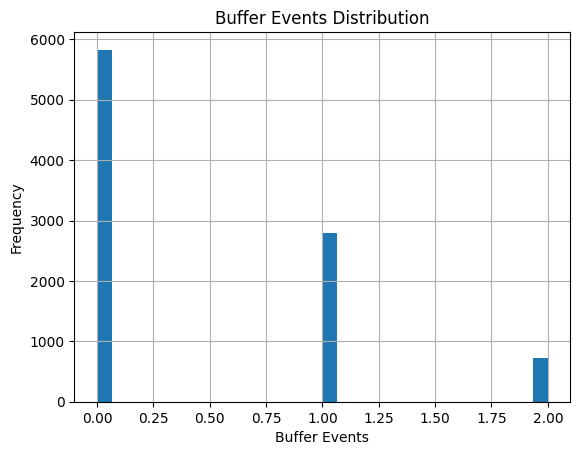

In [12]:
import matplotlib.pyplot as plt

df['buffer_events'].hist(bins=30)
plt.title("Buffer Events Distribution")
plt.xlabel("Buffer Events")
plt.ylabel("Frequency")
plt.show()

Latency vs Buffering

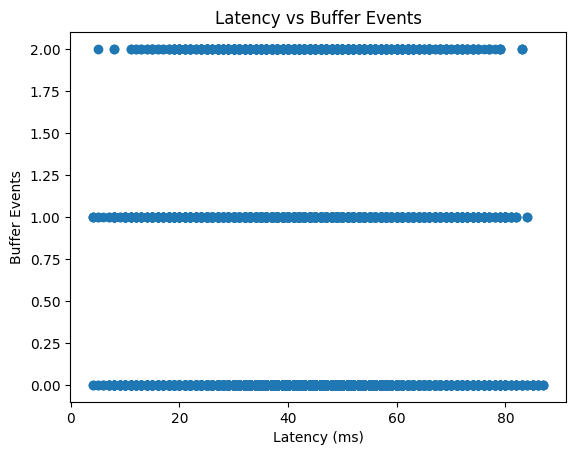

In [14]:
plt.scatter(df['latency_ms'], df['buffer_events'])
plt.xlabel("Latency (ms)")
plt.ylabel("Buffer Events")
plt.title("Latency vs Buffer Events")
plt.show()

CDN Performance

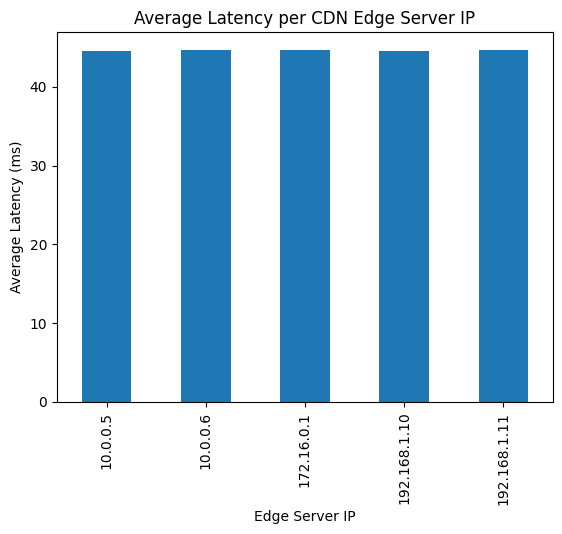

In [16]:
df.groupby('edge_server_ip')['latency_ms'].mean().plot(kind='bar')
plt.title("Average Latency per CDN Edge Server IP")
plt.xlabel("Edge Server IP")
plt.ylabel("Average Latency (ms)")
plt.show()

Event Distribution

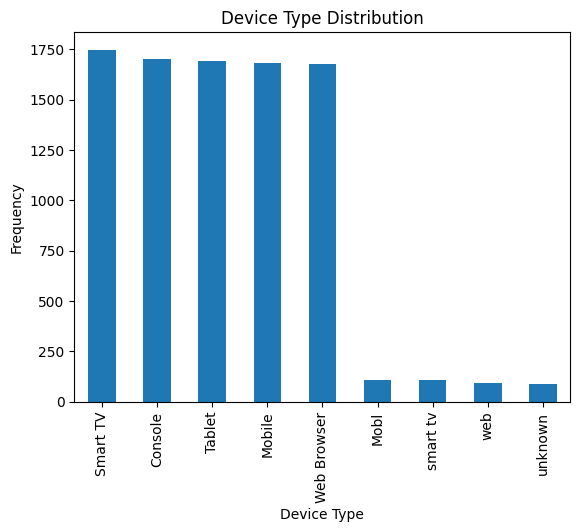

In [18]:
df['device_type'].value_counts().plot(kind='bar')
plt.title("Device Type Distribution")
plt.xlabel("Device Type")
plt.ylabel("Frequency")
plt.show()

Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

X = df[['bitrate_kbps', 'latency_ms', 'device_type_encoded', 'hour']]
y = df['buffer_flag']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7472, 4)
Test shape: (1869, 4)


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5628678437667202
              precision    recall  f1-score   support

           0       0.61      0.80      0.69      1150
           1       0.36      0.18      0.24       719

    accuracy                           0.56      1869
   macro avg       0.49      0.49      0.47      1869
weighted avg       0.51      0.56      0.52      1869



Handle Class Imbalance

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_resampled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

Use Better Model

In [27]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1  # helps imbalance
)

model.fit(X_resampled, y_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

Evaluate Again

In [28]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5243445692883895
              precision    recall  f1-score   support

           0       0.62      0.59      0.60      1150
           1       0.39      0.42      0.40       719

    accuracy                           0.52      1869
   macro avg       0.50      0.50      0.50      1869
weighted avg       0.53      0.52      0.53      1869



In [30]:
# Interaction features
df['latency_per_bitrate'] = df['latency_ms'] / (df['bitrate_kbps'] + 1)

# High latency flag
df['high_latency'] = (df['latency_ms'] > 80).astype(int)

# High bitrate flag
df['high_bitrate'] = (df['bitrate_kbps'] > 3000).astype(int)

In [32]:
X = df[['bitrate_kbps', 'latency_ms', 'device_type_encoded', 'hour',
        'latency_per_bitrate', 'high_latency', 'high_bitrate']]

Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [4, 6, 8],
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(XGBClassifier(), params, cv=3)
grid.fit(X_resampled, y_resampled)

model = grid.best_estimator_

Real-Time Processing Simulation

In [34]:
def process_log(log):
    if log['buffer_time'] > 200:
        return "High Buffering"
    elif log['bitrate'] < 1500:
        return "Low Quality"
    elif log['event'] == 'buffer':
        return "Buffer Event"
    else:
        return "Normal"

Apply Processing to All Logs

In [36]:
# Redefine process_log to use correct column names available in df
def process_log(log):
    if log['bitrate_kbps'] < 1500:
        return "Low Quality"
    elif log['buffer_events'] > 1:
        return "High Buffering"
    elif log['buffer_events'] == 1:
        return "Buffer Event"
    else:
        return "Normal"

df['issue'] = df.apply(process_log, axis=1)
df[['buffer_events', 'bitrate_kbps', 'issue']].head()

,buffer_events,bitrate_kbps,issue
0,0,2766,Normal
1,0,3282,Normal
2,1,3715,Buffer Event
3,0,4720,Normal
4,0,3648,Normal


Analytics Engine

In [38]:
# Average metrics
avg_buffer = df['buffer_events'].mean()
avg_latency = df['latency_ms'].mean()
avg_bitrate = df['bitrate_kbps'].mean()

print("Avg Buffer:", avg_buffer)
print("Avg Latency:", avg_latency)
print("Avg Bitrate:", avg_bitrate)

Avg Buffer: 0.4534846376190986
Avg Latency: 44.63847553795097
Avg Bitrate: 2992.7548442350926


In [39]:
df['issue'].value_counts()

,count
issue,
Normal,5668
Buffer Event,2713
High Buffering,699
Low Quality,261


In [41]:
df.groupby('edge_server_ip')['latency_ms'].mean().sort_values()

,latency_ms
edge_server_ip,
10.0.0.5,44.581206
192.168.1.10,44.600435
192.168.1.11,44.637620
10.0.0.6,44.665067
172.16.0.1,44.705142


In [43]:
df.groupby('edge_server_ip')[['buffer_events', 'latency_ms']].mean()

,buffer_events,latency_ms
edge_server_ip,,
10.0.0.5,0.460076,44.581206
10.0.0.6,0.459733,44.665067
172.16.0.1,0.439664,44.705142
192.168.1.10,0.476320,44.600435
192.168.1.11,0.432519,44.637620


Decision Engine

In [44]:
def decision_engine(log):
    if log['buffer_time'] > 200:
        return "Reduce Bitrate"
    elif log['latency'] > 100:
        return "Switch CDN"
    elif log['bitrate'] < 1500:
        return "Increase Bitrate"
    else:
        return "No Action"

In [46]:
def decision_engine(log):
    if log['buffer_events'] > 1:
        return "Reduce Bitrate"
    elif log['latency_ms'] > 100:
        return "Switch CDN"
    elif log['bitrate_kbps'] < 1500:
        return "Increase Bitrate"
    else:
        return "No Action"

df['action'] = df.apply(decision_engine, axis=1)
df[['buffer_events', 'latency_ms', 'bitrate_kbps', 'action']].head()

,buffer_events,latency_ms,bitrate_kbps,action
0,0,35,2766,No Action
1,0,47,3282,No Action
2,1,45,3715,No Action
3,0,29,4720,No Action
4,0,52,3648,No Action


Aggregation

In [48]:
# Buffer rate
buffer_rate = df['buffer_flag'].mean()

# Error-like events (buffer events) - using buffer_flag as a direct indicator
error_rate = df['buffer_flag'].mean()

print("Buffer Rate:", buffer_rate)
print("Error Rate:", error_rate)

Buffer Rate: 0.37608393105663207
Error Rate: 0.37608393105663207


Visualization

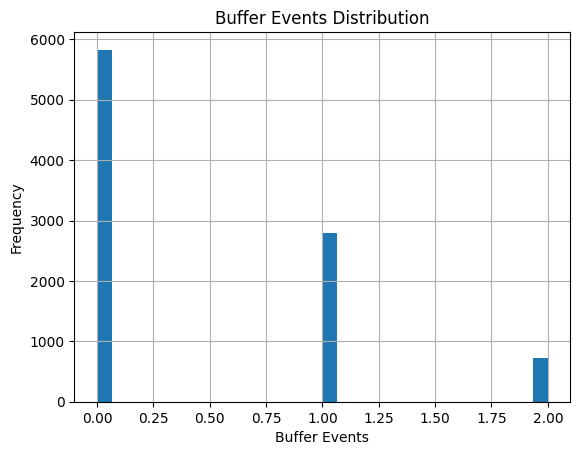

In [50]:
import matplotlib.pyplot as plt

df['buffer_events'].hist(bins=30)
plt.title("Buffer Events Distribution")
plt.xlabel("Buffer Events")
plt.ylabel("Frequency")
plt.show()

Histogram


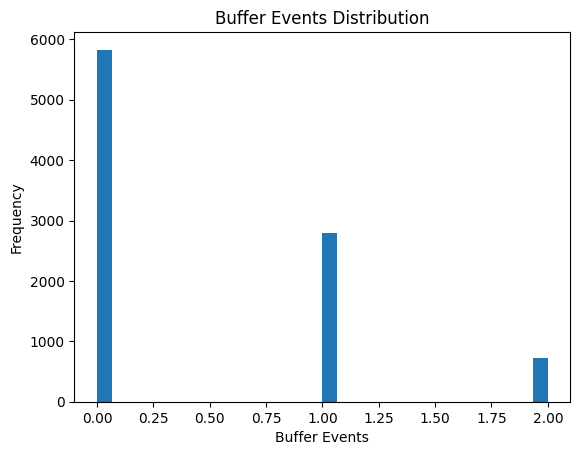

In [52]:
import matplotlib.pyplot as plt

# Example: buffer_events distribution
plt.hist(df['buffer_events'], bins=30)
plt.title("Buffer Events Distribution")
plt.xlabel("Buffer Events")
plt.ylabel("Frequency")
plt.show()

KDE Plot

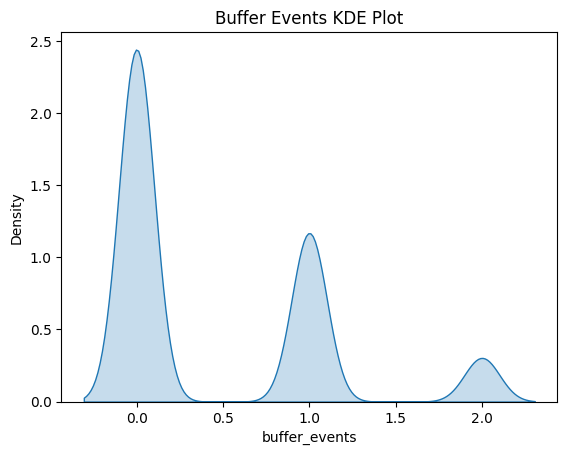

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['buffer_events'], fill=True)
plt.title("Buffer Events KDE Plot")
plt.show()

Q-Q Plot

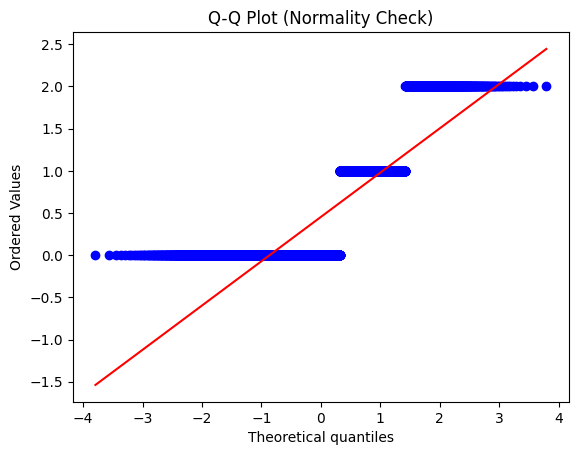

In [56]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['buffer_events'], dist="norm", plot=plt)
plt.title("Q-Q Plot (Normality Check)")
plt.show()

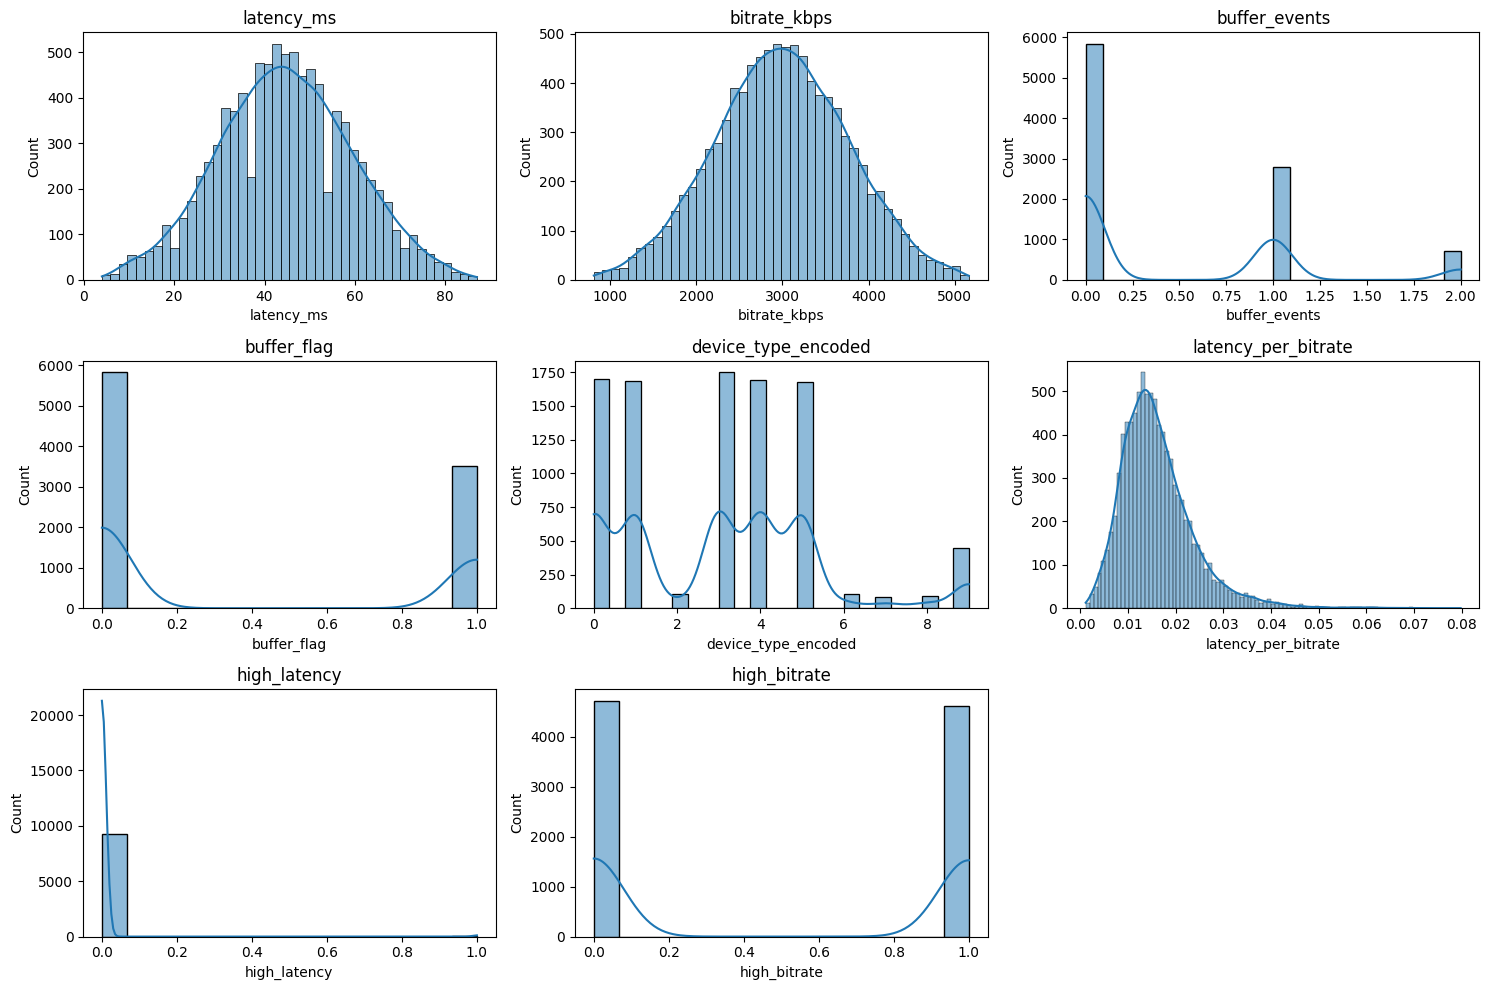

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)   # adjust rows/cols if needed
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()